In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from collections import Counter

# ----------------------------------------------------
# 1. Charger le dataset complet
# ----------------------------------------------------
df = pd.read_csv("data.csv")  # ton fichier complet

print("Shape du dataset:", df.shape)
print("Colonnes:", df.columns.tolist())


Shape du dataset: (99999, 46)
Colonnes: ['day', 'month', 'year', 'Region', 'lat', 'lon', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'VPD', 'drought_index', 'FM100', 'FM1000', 'ERC', 'BI', 'soil_moisture_surface', 'NDVI', 'dNBR', 'FRP', 'elevation', 'slope', 'dist_road', 'dist_city', 'pop_density', 'SVI', 'road_density', 'houses_near', 'fuel_type', 'land_use', 'previous_burn', 'powerline_near', 'camping_sites_near', 'preparedness_level', 'human_cause', 'lightning_cause', 'season', 'day_part', 'year_period', 'Classes']


In [2]:
# ----------------------------------------------------
# 2. Nettoyage / typage simple
#    (on ne supprime aucune colonne, on les garde toutes)
# ----------------------------------------------------
# On convertit tout ce qui n'est pas numérique en string propre
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()

# ----------------------------------------------------
# 3. Construire les transactions (attribut=valeur)
#    On utilise TOUTES les colonnes SAUF la cible 'Classes'
#    (mais on rajoute aussi Classes comme item car c'est important)
# ----------------------------------------------------
feature_cols = [c for c in df.columns if c != "Classes"]
target_col = "Classes"

transactions = []
for _, row in df.iterrows():
    items = []
    # attributs explicatifs
    for col in feature_cols:
        val = row[col]
        items.append(f"{col}={val}")
    # ajouter la classe comme item
    items.append(f"{target_col}={row[target_col]}")
    transactions.append(items)

print("Exemple de transaction:")
print(transactions[0])


Exemple de transaction:
['day=21', 'month=10', 'year=2024', 'Region=SouthAmerica', 'lat=low', 'lon=low', 'Temperature=med', 'RH=high', 'Ws=med', 'Rain=low', 'FFMC=high', 'DMC=low', 'DC=med', 'ISI=low', 'BUI=med', 'FWI=low', 'VPD=low', 'drought_index=low', 'FM100=med', 'FM1000=low', 'ERC=med', 'BI=med', 'soil_moisture_surface=med', 'NDVI=med', 'dNBR=med', 'FRP=low', 'elevation=low', 'slope=low', 'dist_road=low', 'dist_city=low', 'pop_density=low', 'SVI=high', 'road_density=med', 'houses_near=low', 'fuel_type=forest', 'land_use=agriculture', 'previous_burn=1', 'powerline_near=0', 'camping_sites_near=0', 'preparedness_level=4', 'human_cause=1', 'lightning_cause=0', 'season=autumn', 'day_part=late', 'year_period=2020s', 'Classes=not fire']


In [3]:
# ----------------------------------------------------
# 4. Encodage one-hot
# ----------------------------------------------------
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

print("Shape one-hot:", df_onehot.shape)


Shape one-hot: (99999, 194)


In [4]:
# ----------------------------------------------------
# 5. Apriori: itemsets fréquents (max_len=4)
#    -> version simple avec minsup=0.05 (à ajuster)
# ----------------------------------------------------
min_support_base = 0.05
frequent_itemsets = apriori(
    df_onehot,
    min_support=min_support_base,
    use_colnames=True,
    max_len=2
)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print("Nombre d'itemsets fréquents (min_support=0.05):", len(frequent_itemsets))
print(frequent_itemsets.sort_values("support", ascending=False).head(10))

Nombre d'itemsets fréquents (min_support=0.05): 4724
       support                                     itemsets  length
96    0.980930                 frozenset({pop_density=low})       1
21    0.972540                         frozenset({FRP=low})       1
57    0.966680                   frozenset({dist_city=low})       1
58    0.963240                   frozenset({dist_road=low})       1
32    0.955960                        frozenset({Rain=low})       1
1812  0.954310        frozenset({pop_density=low, FRP=low})       2
3687  0.948009  frozenset({pop_density=low, dist_city=low})       2
3748  0.945169  frozenset({pop_density=low, dist_road=low})       2
1774  0.939779          frozenset({dist_city=low, FRP=low})       2
2556  0.937789       frozenset({pop_density=low, Rain=low})       2


In [5]:
# ----------------------------------------------------
# 6. Règles d'association
# ----------------------------------------------------
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5  # confiance minimale
)

print("Nombre total de règles:", len(rules))
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# Règles où la conséquence contient Classes=fire
rules_fire = rules[rules['consequents'].astype(str).str.contains('Classes=fire')]
print("Nombre de règles vers 'Classes=fire':", len(rules_fire))

Nombre total de règles: 3605
            antecedents                        consequents   support  \
0  frozenset({BI=high})               frozenset({FRP=low})  0.062281   
1  frozenset({BI=high})              frozenset({Rain=low})  0.060701   
2  frozenset({BI=high})  frozenset({camping_sites_near=0})  0.058271   
3  frozenset({BI=high})         frozenset({dist_city=low})  0.061831   
4  frozenset({BI=high})         frozenset({dist_road=low})  0.060921   
5  frozenset({BI=high})     frozenset({lightning_cause=0})  0.053361   
6  frozenset({BI=high})       frozenset({pop_density=low})  0.062861   
7  frozenset({BI=high})      frozenset({powerline_near=0})  0.053021   
8  frozenset({BI=high})       frozenset({previous_burn=0})  0.052751   
9  frozenset({BI=high})      frozenset({road_density=low})  0.058461   

   confidence      lift  
0    0.974648  1.002168  
1    0.949922  0.993684  
2    0.911894  1.014501  
3    0.967606  1.000958  
4    0.953365  0.989748  
5    0.835055  0.97894

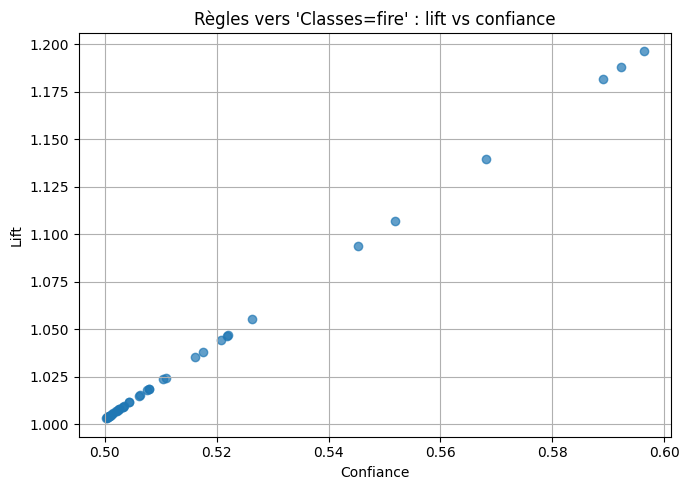

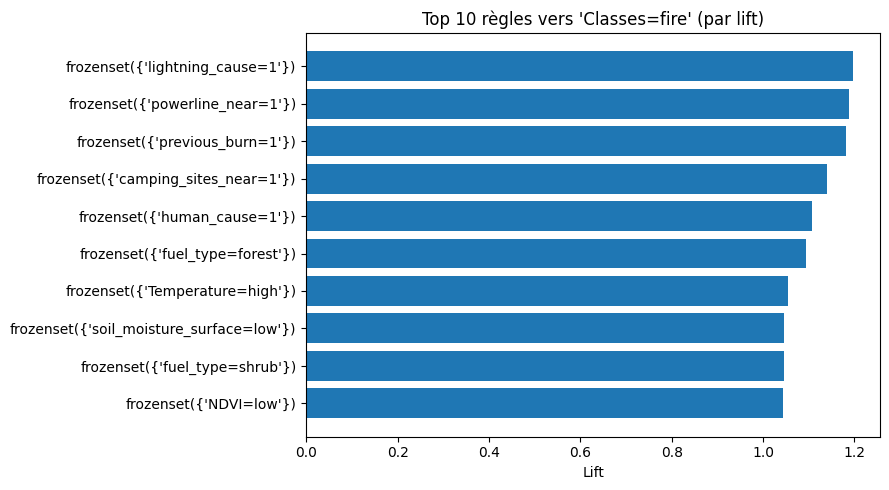

In [6]:
# ----------------------------------------------------
# 7. Graphique: lift vs confiance pour les règles vers 'fire'
# ----------------------------------------------------
if len(rules_fire) > 0:
    plt.figure(figsize=(7,5))
    plt.scatter(rules_fire['confidence'], rules_fire['lift'], alpha=0.7)
    plt.xlabel('Confiance')
    plt.ylabel('Lift')
    plt.title("Règles vers 'Classes=fire' : lift vs confiance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Top 10 règles par lift
    top_rules = rules_fire.sort_values('lift', ascending=False).head(10)

    plt.figure(figsize=(9,5))
    plt.barh(
        range(len(top_rules)),
        top_rules['lift'],
        tick_label=top_rules['antecedents'].astype(str)
    )
    plt.xlabel('Lift')
    plt.title("Top 10 règles vers 'Classes=fire' (par lift)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


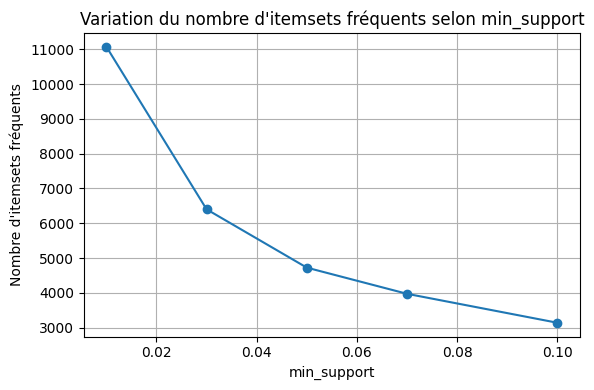

In [7]:
# ----------------------------------------------------
# 8. Effet de minsup sur le nombre d'itemsets fréquents
# ----------------------------------------------------
minsups = [0.01, 0.03, 0.05, 0.07, 0.1]
counts = []

for ms in minsups:
    fi = apriori(df_onehot, min_support=ms, use_colnames=True, max_len=2)
    counts.append(len(fi))

plt.figure(figsize=(6,4))
plt.plot(minsups, counts, marker='o')
plt.xlabel('min_support')
plt.ylabel("Nombre d'itemsets fréquents")
plt.title("Variation du nombre d'itemsets fréquents selon min_support")
plt.grid(True)
plt.tight_layout()
plt.show()

Items les plus fréquents dans les antécédents des règles vers 'Classes=fire':
BI=low : 1
DC=med : 1
DMC=med : 1
ERC=med : 1
FFMC=high : 1
FM1000=low : 1
FM100=med : 1
FWI=med : 1
ISI=low : 1
NDVI=low : 1
NDVI=med : 1
RH=low : 1
Rain=low : 1
Region=AfricaOther : 1
Region=RussiaSiberia : 1


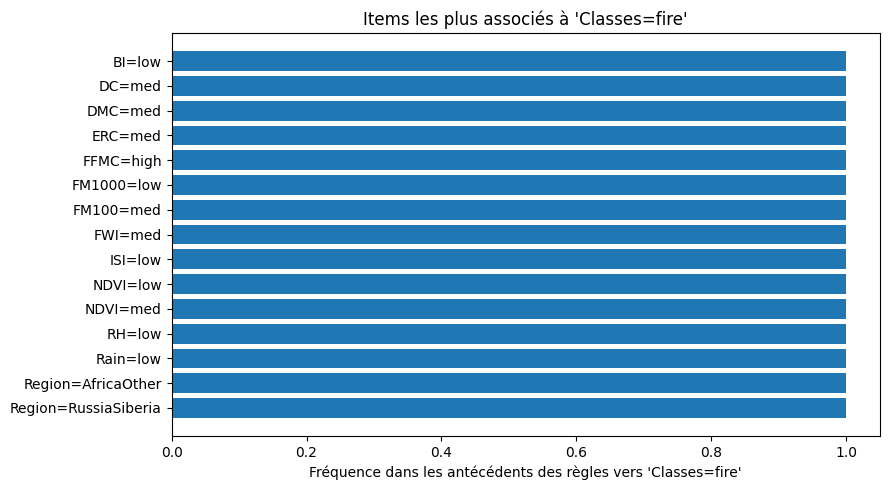

In [8]:
# ----------------------------------------------------
# 9. "Attributs importants" (items les plus associés à fire)
# ----------------------------------------------------
antecedent_items = []
for ants in rules_fire['antecedents']:
    for a in ants:
        antecedent_items.append(a)

counter_items = Counter(antecedent_items)
top_items = counter_items.most_common(15)
print("Items les plus fréquents dans les antécédents des règles vers 'Classes=fire':")
for item, cnt in top_items:
    print(item, ":", cnt)

# Graphique des items les plus fréquents
if len(top_items) > 0:
    labels = [x[0] for x in top_items]
    values = [x[1] for x in top_items]

    plt.figure(figsize=(9,5))
    plt.barh(range(len(labels)), values, tick_label=labels)
    plt.xlabel("Fréquence dans les antécédents des règles vers 'Classes=fire'")
    plt.title("Items les plus associés à 'Classes=fire'")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Nombre total d'observations: 99999
Distribution de la classe:
Classes
not fire    50142
fire        49857
Name: count, dtype: int64


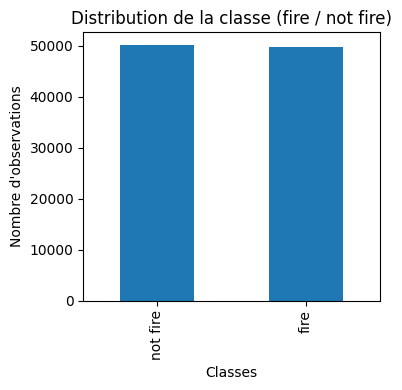

In [9]:
# ----------------------------------------------------
# 10. Récapitulatif statistique simple
# ----------------------------------------------------
n_total = len(df)
class_counts = df['Classes'].value_counts()

print("Nombre total d'observations:", n_total)
print("Distribution de la classe:")
print(class_counts)

# Graphique distribution fire / not fire
plt.figure(figsize=(4,4))
class_counts.plot(kind='bar')
plt.title("Distribution de la classe (fire / not fire)")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()